In [1]:
import numpy as np
from numba import njit , prange
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from joblib import Parallel, delayed
from scipy.stats import skew
from scipy.ndimage import uniform_filter1d
from scipy.signal import hilbert
import pandas as pd
from tqdm import tqdm
import progressbar 
import os, json, time, gc, io, contextlib, math
from numba import set_num_threads, get_num_threads
from operator import mod
from itertools import product
from statsmodels.tsa.stattools import adfuller
from itertools import permutations
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import TwoSlopeNorm
import glob
import imageio.v2 as imageio
from scipy.integrate import solve_ivp
from math import comb
from scipy.interpolate import interp1d
from pathlib import Path
from loguru import logger
import typer
import sys
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import minimize_scalar
from scipy.optimize import minimize
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from scipy.stats import gaussian_kde
from scipy.stats import rayleigh, gamma, lognorm
from scipy.stats import ecdf

PROJ_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJ_ROOT))
REPORTS_DIR = PROJ_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
DATA_DIR = PROJ_ROOT / "data" / "raw"

import moran.methods as methods
import moran.config as config
import moran.plots as plots

g=1

2026-07-13 11:02:05.899 | INFO     | moran.config:<module>:11 - PROJ_ROOT path is: C:\Users\ah741\Desktop\fitness_waves


In [2]:
ZERO_NONE = 0
ZERO_PAIR_RANDOM = 1
ZERO_PAIR_TAILS = 2
ZERO_GAUSSIAN_PAIRS = 3
ZERO_CUBIC = 4
ZERO_LOCAL_TRIPLE = 5


In [ ]:
b1_rate = 0.02; b2_rate = 0; d1_rate = 0.02; d2_rate = 0; tmax = 200; skip = 100; t_lag = 100; n_individuals = 10000; trait_values = np.zeros(n_individuals); indices = np.arange(skip*n_individuals, tmax*n_individuals, t_lag) 

In [ ]:
b1_rate = 0.1; b2_rate = 0; d1_rate = 0.1; d2_rate = 0; tmax = 400; skip = 100; t_lag = 10; n_individuals = 1000; trait_values = np.zeros(n_individuals); indices = np.arange(skip*n_individuals, tmax*n_individuals, t_lag) 

In [15]:
Main_3D, Moments = methods.Quad_Sim_V00(b1_rate, b2_rate, d1_rate, d2_rate, tmax, indices, trait_values)

In [29]:
All_tv, Main_3D, Clipp, Moments, Moments_right_tail, Moments_left_tail, Hist_counts, Hist_edges = methods.Quad_Sim_V2(b1_rate, b2_rate, d1_rate, d2_rate, tmax, indices, trait_values, nbins=128)

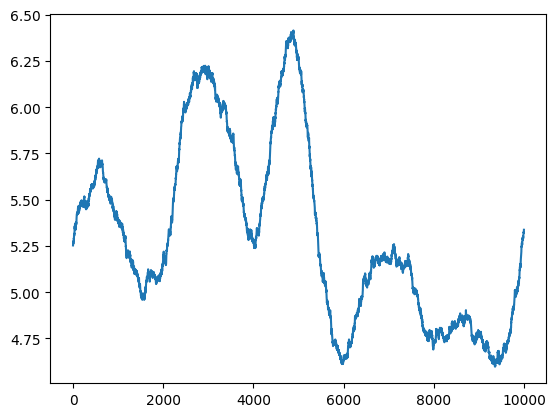

In [17]:
plt.plot(Main_3D[2,:])
plt.show()

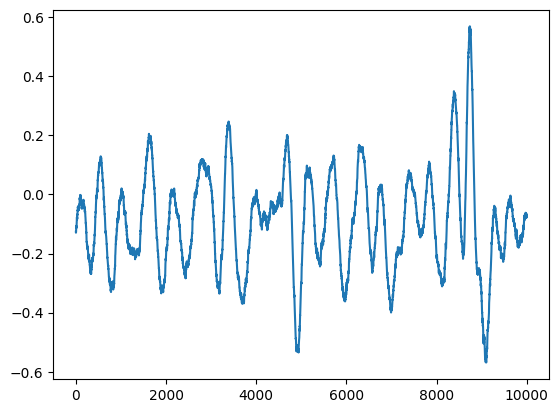

In [13]:
plt.plot(Main_3D[1,:])
plt.show()

In [30]:
All_tv.shape

(30000, 10000)

In [40]:
np.mean(All_tv[20000,:]**2)

np.float64(15.09119078196715)

In [35]:
methods.zero_skew_population_inplace(All_tv[20000,:], ZERO_CUBIC)

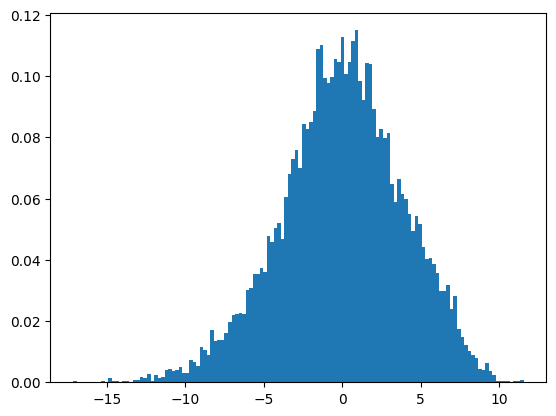

In [31]:
plt.hist(All_tv[20000,:], bins=128, density=True)
plt.show()

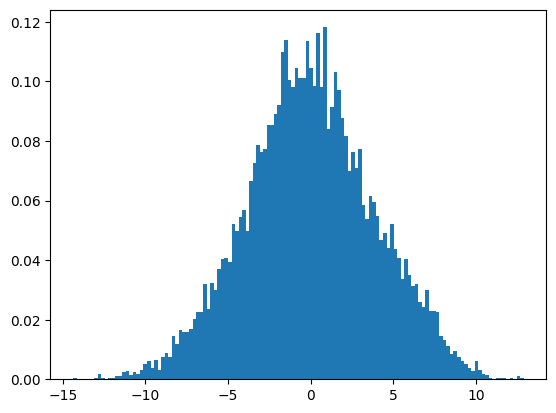

In [36]:
plt.hist(All_tv[20000,:], bins=128, density=True)
plt.show()

In [15]:
Main_3D2 = methods.Quad_Sim_V00_zeroSkew(b1_rate,    b2_rate,    d1_rate,    d2_rate,    tmax,    indices,    trait_values,    ZERO_CUBIC,    1)

In [6]:
Main_3D2 = methods.Quad_Sim_V00_zeroSkew(b1_rate,    b2_rate,    d1_rate,    d2_rate,    tmax,    indices,    trait_values,    ZERO_GAUSSIAN_PAIRS,    1)

In [20]:
Main_3D2, Clipp, Moments, Moments_right_tail, Moments_left_tail, Hist_counts, Hist_edges   = methods.Quad_Sim_V1_zeroSkew(    b1_rate,    b2_rate,    d1_rate,    d2_rate,    tmax,    indices,    trait_values,    nbins=128,    zero_method=ZERO_CUBIC,    zero_every_events=1)

In [10]:
Hist_counts.shape

(30000, 128)

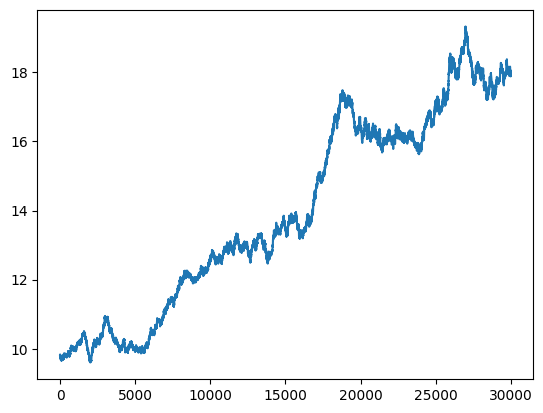

In [8]:
plt.plot(Main_3D2[2,:])
plt.show()

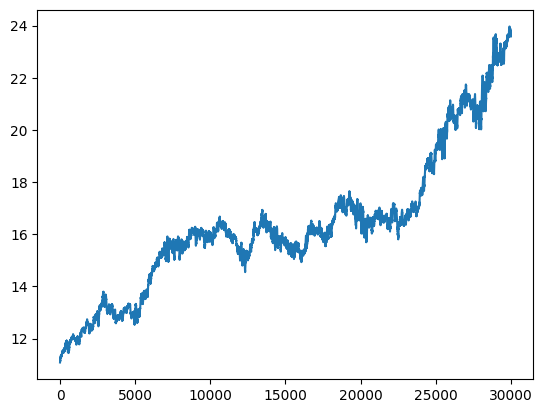

In [46]:
plt.plot(Main_3D2[2,:])
plt.show()

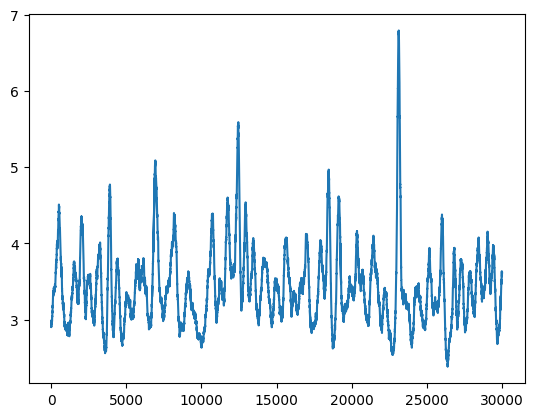

In [23]:
plt.plot(Main_3D[2,:])
plt.show()

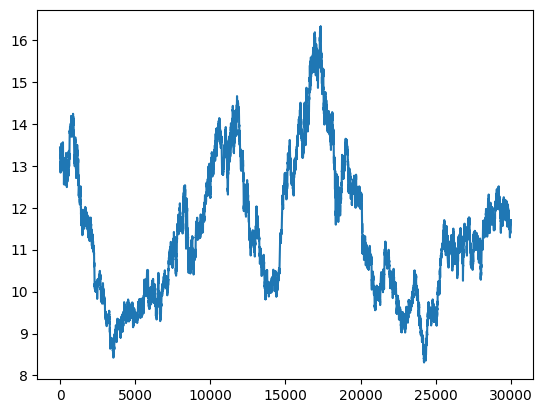

In [ ]:
plt.plot(Main_3D2[2,:])
plt.show()